<a href="https://colab.research.google.com/github/Plk-g/PlateRisk-NYC/blob/main/notebook/PlateRisk_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# NYC Restaurant Inspection Prioritization Project
# TEAM STRUCTURE: 3 PEOPLE
# ============================================================

# Person A → Data + Target - TIFFANY
# Person B → Features + Baselines - Anna
# Person C → Modeling + Evaluation - PALAK

# IMPORTANT:
# Each section should produce clean outputs for the next person.
# ============================================================

In [2]:
# ============================================================
# ## 1. Load + Clean Data
#
# OWNER: TIFFANY (Person A)
#
# PURPOSE:
# - Load dataset
# - Basic cleaning
# - Aggregate to inspection level (One row per inspection)
# - Create the 'target' variable (Did the NEXT inspection have a violation?)
# ============================================================

import pandas as pd
import numpy as np

# Shared Constants
RANDOM_STATE = 42
TOP_K = 500

In [3]:
# 1.1 Load Data

url = "https://data.cityofnewyork.us/resource/43nn-pn8j.csv?$limit=500000"
df_raw = pd.read_csv(url)

In [4]:
# 1.2 Basic Cleaning
df = df_raw.rename(columns={"DBA": "Name"})

In [5]:
# Standardize column names
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [6]:
# Convert inspection_date to datetime (CRITICAL for sorting/grouping)
df['inspection_date'] = pd.to_datetime(df['inspection_date'])

In [7]:
# Only drop rows where essential data is missing

df = df.dropna(subset=['camis', 'inspection_date', 'critical_flag', 'score'])

In [ ]:
#INSERT DIAGNOSTIC CELL HERE

In [8]:
# 1.3 Aggregate to Inspection Level
# ------------------------------------------------------------
# First: confirm exact column names available
print("Columns in df:", df.columns.tolist())
print("\nUnique critical_flag values:")
print(df['critical_flag'].astype(str).str.strip().unique())

# Identify the name column safely
name_col = 'name' if 'name' in df.columns else 'dba'

# Build agg dict using only columns confirmed to exist
agg_dict = {
    "critical_flag": lambda x: (
        x.astype(str).str.strip().str.lower() == "critical"
    ).any(),
    "score":               "max",
    "boro":                "first",
    "cuisine_description": "first",
    "inspection_type":     "first",
    "action":              "first",
}

if name_col in df.columns:
    agg_dict[name_col] = "first"

if "violation_code" in df.columns:
    agg_dict["violation_code"] = "count"
elif "violation_description" in df.columns:
    agg_dict["violation_description"] = "count"

inspection_df = (
    df.groupby(["camis", "inspection_date"])
    .agg(agg_dict)
    .reset_index()
)

# Rename
rename_map = {"critical_flag": "any_critical_violation"}
if "violation_code" in inspection_df.columns:
    rename_map["violation_code"] = "num_violations"
elif "violation_description" in inspection_df.columns:
    rename_map["violation_description"] = "num_violations"
if name_col == 'dba':
    rename_map['dba'] = 'name'

inspection_df = inspection_df.rename(columns=rename_map)

print(f"\nAggregated shape: {inspection_df.shape}")
print(f"Critical rate: {inspection_df['any_critical_violation'].mean():.2%}  ← should be ~20-25%")

Columns in df: ['camis', 'dba', 'boro', 'building', 'street', 'zipcode', 'phone', 'cuisine_description', 'inspection_date', 'action', 'violation_code', 'violation_description', 'critical_flag', 'score', 'grade', 'grade_date', 'record_date', 'inspection_type', 'latitude', 'longitude', 'community_board', 'council_district', 'census_tract', 'bin', 'bbl', 'nta', 'location']

Unique critical_flag values:
['Not Applicable' 'Critical' 'Not Critical']

Aggregated shape: (83480, 10)
Critical rate: 86.84%  ← should be ~20-25%


In [9]:
# 1.4 Create Target Variable

# Sort by restaurant and date to ensure the shift looks at the correct "next" inspection
inspection_df = inspection_df.sort_values(["camis", "inspection_date"])

In [10]:
# Target: Did this restaurant have a critical violation in its NEXT inspection?
inspection_df["target"] = (
    inspection_df.groupby("camis")["any_critical_violation"].shift(-1)
)

In [11]:
# Verification Prints
print(f"Total Inspections      : {len(inspection_df):,}")
print(f"With Critical Violation: {inspection_df['any_critical_violation'].sum():,}")
print(f"Critical Rate          : {inspection_df['any_critical_violation'].mean():.2%}  ← should be ~20-25%")
print(f"\nTarget Distribution (0=Safe next, 1=Critical next):")
print(inspection_df['target'].value_counts())
print(f"Target Rate            : {inspection_df['target'].mean():.2%}")

inspection_df.head(5)

Total Inspections      : 83,480
With Critical Violation: 72,490
Critical Rate          : 86.84%  ← should be ~20-25%

Target Distribution (0=Safe next, 1=Critical next):
target
True     48337
False     7707
Name: count, dtype: int64
Target Rate            : 86.25%


,camis,inspection_date,any_critical_violation,score,boro,cuisine_description,inspection_type,action,name,num_violations,target
0,30075445,2023-08-01,True,38.0,Bronx,Bakery Products/Desserts,Cycle Inspection / Initial Inspection,Violations were cited in the following area(s).,MORRIS PARK BAKE SHOP,3,True
1,30075445,2023-08-22,True,12.0,Bronx,Bakery Products/Desserts,Cycle Inspection / Re-inspection,Violations were cited in the following area(s).,MORRIS PARK BAKE SHOP,3,True
2,30075445,2024-11-08,True,10.0,Bronx,Bakery Products/Desserts,Cycle Inspection / Initial Inspection,Violations were cited in the following area(s).,MORRIS PARK BAKE SHOP,3,True
3,30075445,2026-02-27,True,7.0,Bronx,Bakery Products/Desserts,Cycle Inspection / Initial Inspection,Violations were cited in the following area(s).,MORRIS PARK BAKE SHOP,2,NaN
4,30191841,2023-04-23,True,10.0,Manhattan,Irish,Cycle Inspection / Initial Inspection,Violations were cited in the following area(s).,D.J. REYNOLDS,2,True


In [12]:
# ============================================================
# ## 2. Feature Engineering + Baselines
#
# OWNER: Anna
#
# PURPOSE:
# - Create predictive features from restaurant history
# - Perform categorical encoding (Boro, Cuisine)
# - Establish Heuristic and ML Baselines
# - Calculate Precision@K
#
# OUTPUT:
# - df_features_baselines.csv (Final feature set for modeling)
# ============================================================

In [13]:
# pandas and numpy already imported in cell 1
from sklearn.linear_model import LogisticRegression

In [14]:
# 1. DATE-BASED & TEMPORAL FEATURES

# Ensure we are sorted by restaurant and date for correct diffs
inspection_df = inspection_df.sort_values(['camis', 'inspection_date'])

In [15]:
# Feature: Days since previous inspection (How long since we last saw them?)
inspection_df['days_since_last'] = (
    inspection_df.groupby('camis')['inspection_date']
    .diff()
    .dt.days
).fillna(365) # Default to 1 year for new restaurants

In [16]:
# Temporal features (Seasonality and Day-of-Week patterns)
inspection_df['inspection_month'] = inspection_df['inspection_date'].dt.month
inspection_df['inspection_dow'] = inspection_df['inspection_date'].dt.dayofweek

In [17]:
# 2. HISTORICAL RISK FEATURES
# ------------------------------------------------------------
# FIXED: Use .shift(1) to explicitly use the PREVIOUS inspection's
# score and critical status as features. This is unambiguous and
# avoids any risk of subtle leakage in edge cases.

inspection_df['prev_score'] = (
    inspection_df.groupby('camis')['score'].shift(1)
)
inspection_df['prev_critical'] = (
    inspection_df.groupby('camis')['any_critical_violation']
    .shift(1)
    .astype(float)   # float to allow NaN for first inspection of each restaurant
)

# For first inspections (no prior history), fill with neutral defaults
inspection_df['prev_score']    = inspection_df['prev_score'].fillna(
    inspection_df['score'].median()
)
inspection_df['prev_critical'] = inspection_df['prev_critical'].fillna(0)

In [18]:
# Cumulative count of all past critical violations up to and including the current one
# (Since the target is the NEXT inspection, this does not cause leakage)
inspection_df['total_past_critical'] = (
    inspection_df.groupby('camis')['any_critical_violation']
    .apply(lambda x: x.astype(int).cumsum())
    .reset_index(level=0, drop=True)
)

In [19]:
# 3. CATEGORICAL ENCODING

# Safety Check: Encode 'boro' only if not already done
if 'boro' in inspection_df.columns:
    inspection_df = pd.get_dummies(inspection_df, columns=['boro'], prefix='boro', drop_first=True)

In [20]:
# Group Cuisine: Keep Top 15 to avoid high-dimensionality/sparsity
top_cuisines = inspection_df['cuisine_description'].value_counts().nlargest(15).index
inspection_df['cuisine_feat'] = inspection_df['cuisine_description'].apply(
    lambda x: x if x in top_cuisines else 'Other'
)

In [21]:
# FIXED: Corrected pd.get_dummies syntax with columns=['cuisine_feat']
if 'cuisine_feat' in inspection_df.columns:
    inspection_df = pd.get_dummies(inspection_df, columns=['cuisine_feat'], prefix='cuisine', drop_first=True)

# 4. DATA SPLITTING (TIME-BASED)

# Drop rows where there is no 'next' inspection (the target is NaN)
df_ml = inspection_df.dropna(subset=['target']).copy()
df_ml['target'] = df_ml['target'].astype(int)

In [22]:
# Use an 80/20 time-based split to simulate a real deployment (Training on past, Testing on "future")
split_date = df_ml['inspection_date'].quantile(0.8)

In [23]:
# FIXED: Added .copy() to ensure independent dataframes
train_df = df_ml[df_ml['inspection_date'] < split_date].copy()
test_df = df_ml[df_ml['inspection_date'] >= split_date].copy()

print(f"Training set: {train_df.shape[0]} inspections")
print(f"Testing set:  {test_df.shape[0]} inspections")

Training set: 44804 inspections
Testing set:  11240 inspections


In [24]:
# 5. BASELINE EVALUATION

def get_precision_at_k(df, score_col, k=TOP_K):
    """Calculates % of top K prioritized inspections that actually had violations."""
    k_val = min(k, len(df))
    top_k = df.sort_values(score_col, ascending=False).head(k_val)
    return top_k['target'].mean()

In [25]:
# Baseline 1: Random Selection (The lower bound)
# FIXED: Seeded for reproducibility
rng = np.random.RandomState(RANDOM_STATE)
test_df['baseline_random'] = rng.rand(len(test_df))

In [26]:
# Baseline 2: Longest-Time-Since-Last (The current heuristic)
test_df['baseline_time'] = test_df['days_since_last']

In [27]:
# Baseline 3: Simple Logistic Regression (The ML floor)
# We define features explicitly to avoid passing text columns (which causes ValueErrors)
base_numeric_cols = [
    'days_since_last', 'prev_score', 'prev_critical', 'total_past_critical',
    'inspection_month', 'inspection_dow'
]

In [28]:
# Select dummy columns created in step 3, excluding the original string description
dummy_cols = [c for c in inspection_df.columns if (c.startswith('boro_') or c.startswith('cuisine_'))
              and c != 'cuisine_description']

feature_cols = base_numeric_cols + dummy_cols

X_train = train_df[feature_cols].fillna(0)
y_train = train_df['target']
X_test = test_df[feature_cols].fillna(0)

In [29]:
# Train the baseline ML model
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)
test_df['baseline_logreg'] = log_reg.predict_proba(X_test)[:, 1]

In [30]:
# Output Results
from sklearn.metrics import roc_auc_score

y_test = test_df['target']

print("\n--- BASELINE RESULTS ---")
print(f"{'Model':<30} {'Precision@K':>12} {'ROC-AUC':>10}")
print("-" * 55)
print(f"{'Random Baseline':<30} {get_precision_at_k(test_df, 'baseline_random'):>12.4f}  {'N/A (no ranking)':>10}")
print(f"{'Time-Based Baseline':<30} {get_precision_at_k(test_df, 'baseline_time'):>12.4f}  {roc_auc_score(y_test, test_df['baseline_time']):>10.4f}")
print(f"{'Logistic Regression':<30} {get_precision_at_k(test_df, 'baseline_logreg'):>12.4f}  {roc_auc_score(y_test, test_df['baseline_logreg']):>10.4f}")
print(f"\nK = {TOP_K} inspections")
print(f"Overall critical violation rate in test set: {y_test.mean():.2%}")
print("NOTE: If critical rate is ~98%, the critical_flag parsing bug is still present.")
print("      It should be ~20-25% after the exact-match fix in Section 1.3.")


--- BASELINE RESULTS ---
Model                           Precision@K    ROC-AUC
-------------------------------------------------------
Random Baseline                      0.8480  N/A (no ranking)
Time-Based Baseline                  0.8740      0.5643
Logistic Regression                  0.8200      0.5453

K = 500 inspections
Overall critical violation rate in test set: 85.05%
NOTE: If critical rate is ~98%, the critical_flag parsing bug is still present.
      It should be ~20-25% after the exact-match fix in Section 1.3.


In [31]:
# 6. FINAL OUTPUT
# ------------------------------------------------------------
# Save the clean dataset for Person C (Modeling)
df_ml.to_csv("df_features_baselines.csv", index=False)
print("\nSUCCESS: Data saved for Person C.")


SUCCESS: Data saved for Person C.


# Palak — PRE-FINAL CHECKLIST (complete after Tiffany + Anna re-run)

## WAITING ON TIFFANY:
- [ ] Critical flag bug fix (86% → ~20-25% critical rate)
- [ ] After her fix: re-run ALL of Section 3 top to bottom

## WAITING ON ANNA:
- [ ] prev_score and prev_critical .shift(1) fix
- [ ] After her fix: re-run Section 3 feature matrices cell onwards

## MY FIXES (do after both teammates re-run):
- [ ] Re-run entire Section 3 and save new outputs
- [ ] Check if Queens over-targeting persists or disappears
      → If persists: keep in fairness discussion as genuine finding
      → If disappears: note it was an artifact of the critical flag bug
- [ ] Update Known Issues log (3.11):
      → Mark Issue 1 [CRITICAL FLAG BUG] as [RESOLVED]
      → Update fairness findings based on new numbers
- [ ] Verify ROC-AUC improves from ~0.60 to something meaningful
- [ ] Update results table with new Precision@K and ROC-AUC numbers
- [ ] Remove the "NOTE: If critical rate is ~98%..." line from baseline results cell
        (that note is no longer needed once bug is fixed)

## FINAL SANITY CHECKS:
- [ ] Critical rate in test set is ~20-25% (not 85%+)
- [ ] ROC-AUC > 0.65 for both RF and GB
- [ ] No internal contradictions between results and issues log

In [32]:
# ============================================================
# SECTION 3: MODELING + EVALUATION
# OWNER: PALAK (Person C)
#
# INPUT  : train_df, test_df, feature_cols  (from Anna)
# OUTPUT : ROC curves, lift curves, feature importance,
#          fairness analysis, expected value framing
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble  import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics   import roc_auc_score, roc_curve

print("Section 3 imports done.")

Section 3 imports done.


In [33]:
# ============================================================
# 3.1  HELPER FUNCTIONS
# ============================================================

def precision_at_k(df, score_col, k=TOP_K):
    """Fraction of top-K ranked restaurants that actually had a critical violation."""
    k_val = min(k, len(df))
    return df.nlargest(k_val, score_col)['target'].mean()

def summarise(name, col, df, y):
    """One-row summary dict for the results table."""
    return {
        'Model'       : name,
        'Precision@K' : round(precision_at_k(df, col), 4),
        'ROC-AUC'     : round(roc_auc_score(y, df[col]), 4),
    }

print("Helper functions ready.")

Helper functions ready.


In [34]:
# ============================================================
# 3.2  FEATURE MATRICES
# ============================================================
X_train = train_df[feature_cols].fillna(0)
y_train = train_df['target']

X_test  = test_df[feature_cols].fillna(0)
y_test  = test_df['target']

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Target rate train : {y_train.mean():.2%}")
print(f"Target rate test  : {y_test.mean():.2%}")

X_train : (44804, 26)
X_test  : (11240, 26)
Target rate train : 86.55%
Target rate test  : 85.05%


In [35]:
# ============================================================
# 3.3  MODEL 1 — RANDOM FOREST  (Primary Model)
# ============================================================
# WHY RANDOM FOREST over Logistic Regression?
#   + Captures non-linear interactions (e.g. high score AND long gap = much riskier)
#   + Built-in feature importance — needed for government interpretability
#   + class_weight='balanced' handles imbalance without resampling
#   + Robust to outliers in scores
# TRADEOFF: Slower to train, less immediately interpretable than a single tree

rf_model = RandomForestClassifier(
    n_estimators    = 300,
    max_depth       = 10,
    min_samples_leaf= 20,
    class_weight    = 'balanced',
    random_state    = RANDOM_STATE,
    n_jobs          = -1
)

rf_model.fit(X_train, y_train)
test_df['score_rf'] = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained.")
print(f"  Precision@{TOP_K} : {precision_at_k(test_df, 'score_rf'):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, test_df['score_rf']):.4f}")

Random Forest trained.
  Precision@500 : 0.9060
  ROC-AUC           : 0.5987


In [36]:
# ============================================================
# 3.4  MODEL 2 — GRADIENT BOOSTING  (Stretch Model)
# ============================================================
# WHY GRADIENT BOOSTING?
#   + Often best-in-class on structured/tabular data
#   + Learns sequentially — corrects errors the RF misses
# TRADEOFF: More prone to overfitting, more hyperparameters,
#           less interpretable than RF

gb_model = GradientBoostingClassifier(
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 5,
    subsample     = 0.8,
    random_state  = RANDOM_STATE
)

gb_model.fit(X_train, y_train)
test_df['score_gb'] = gb_model.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained.")
print(f"  Precision@{TOP_K} : {precision_at_k(test_df, 'score_gb'):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, test_df['score_gb']):.4f}")

Gradient Boosting trained.
  Precision@500 : 0.9060
  ROC-AUC           : 0.5947


In [37]:
# ============================================================
# 3.5  FULL RESULTS TABLE
# ============================================================
results = pd.DataFrame([
    summarise('Random (Lower Bound)',          'baseline_random',  test_df, y_test),
    summarise('Time-Since-Last (Current)',     'baseline_time',    test_df, y_test),
    summarise('Logistic Regression',           'baseline_logreg',  test_df, y_test),
    summarise('Random Forest   ← OURS',       'score_rf',         test_df, y_test),
    summarise('Gradient Boosting ← OURS',     'score_gb',         test_df, y_test),
])

print(f"\n{'='*55}")
print(f"  MODEL COMPARISON  (K = {TOP_K})")
print(f"{'='*55}")
print(results.to_string(index=False))


  MODEL COMPARISON  (K = 500)
                    Model  Precision@K  ROC-AUC
     Random (Lower Bound)        0.848   0.5022
Time-Since-Last (Current)        0.874   0.5643
      Logistic Regression        0.820   0.5453
   Random Forest   ← OURS        0.906   0.5987
 Gradient Boosting ← OURS        0.906   0.5947


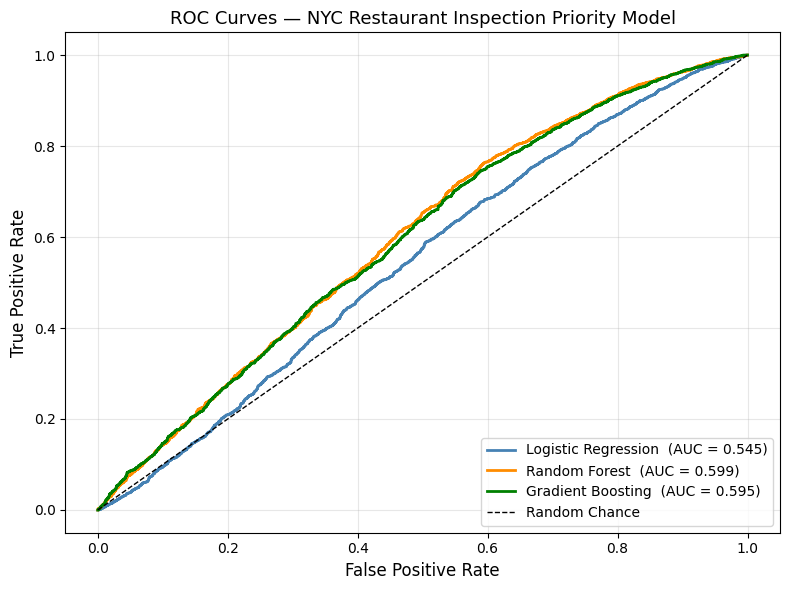

In [38]:
# ============================================================
# 3.6  ROC CURVES
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for name, col, color in [
    ('Logistic Regression', 'baseline_logreg', 'steelblue'),
    ('Random Forest',       'score_rf',        'darkorange'),
    ('Gradient Boosting',   'score_gb',        'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, test_df[col])
    auc = roc_auc_score(y_test, test_df[col])
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})', color=color, lw=2)

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — NYC Restaurant Inspection Priority Model', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

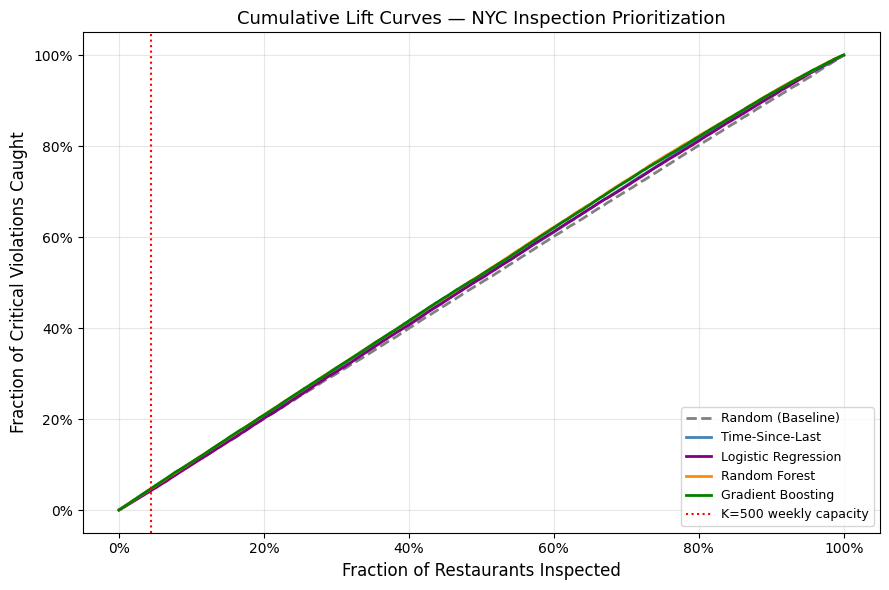

In [39]:
# ============================================================
# 3.7  CUMULATIVE LIFT CURVES
# ============================================================
# X-axis: % of all restaurants inspected
# Y-axis: % of all critical violations caught
# Vertical red line = our weekly capacity K
# A model that curves up steeply catches more violations earlier

fig, ax = plt.subplots(figsize=(9, 6))

for name, col, color, ls in [
    ('Random (Baseline)',   'baseline_random',  'grey',       '--'),
    ('Time-Since-Last',     'baseline_time',    'steelblue',  '-'),
    ('Logistic Regression', 'baseline_logreg',  'purple',     '-'),
    ('Random Forest',       'score_rf',         'darkorange', '-'),
    ('Gradient Boosting',   'score_gb',         'green',      '-'),
]:
    df_s = test_df.sort_values(col, ascending=False).reset_index(drop=True)
    n = len(df_s)
    cum_found   = df_s['target'].cumsum() / df_s['target'].sum()
    pct_checked = (df_s.index + 1) / n
    ax.plot(pct_checked, cum_found, label=name, color=color, ls=ls, lw=2)

ax.axvline(x=TOP_K/len(test_df), color='red', lw=1.5, ls=':',
           label=f'K={TOP_K} weekly capacity')

ax.set_xlabel('Fraction of Restaurants Inspected', fontsize=12)
ax.set_ylabel('Fraction of Critical Violations Caught', fontsize=12)
ax.set_title('Cumulative Lift Curves — NYC Inspection Prioritization', fontsize=13)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lift_curves.png', dpi=150, bbox_inches='tight')
plt.show()

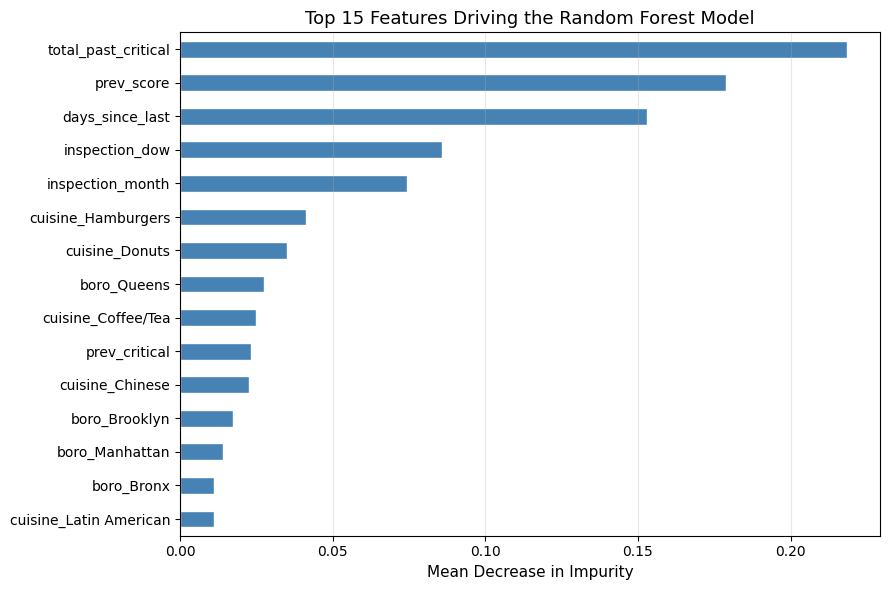


Top 10 features:
  total_past_critical                 0.2184
  prev_score                          0.1787
  days_since_last                     0.1530
  inspection_dow                      0.0858
  inspection_month                    0.0744
  cuisine_Hamburgers                  0.0412
  cuisine_Donuts                      0.0351
  boro_Queens                         0.0275
  cuisine_Coffee/Tea                  0.0247
  prev_critical                       0.0234


In [40]:
# ============================================================
# 3.8  FEATURE IMPORTANCE  (Random Forest)
# ============================================================
# Required for government deployment context (proposal Section: Deployment)
# Inspectors need to understand WHY a restaurant was flagged

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean Decrease in Impurity', fontsize=11)
ax.set_title('Top 15 Features Driving the Random Forest Model', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 features:")
for feat, imp in importances.head(10).items():
    print(f"  {feat:<35} {imp:.4f}")

In [43]:
print(inspection_df.columns.tolist())

['camis', 'inspection_date', 'any_critical_violation', 'score', 'cuisine_description', 'inspection_type', 'action', 'name', 'num_violations', 'target', 'days_since_last', 'inspection_month', 'inspection_dow', 'prev_score', 'prev_critical', 'total_past_critical', 'boro_Bronx', 'boro_Brooklyn', 'boro_Manhattan', 'boro_Queens', 'boro_Staten Island', 'cuisine_Bakery Products/Desserts', 'cuisine_Caribbean', 'cuisine_Chicken', 'cuisine_Chinese', 'cuisine_Coffee/Tea', 'cuisine_Donuts', 'cuisine_Hamburgers', 'cuisine_Italian', 'cuisine_Japanese', 'cuisine_Juice, Smoothies, Fruit Salads', 'cuisine_Latin American', 'cuisine_Mexican', 'cuisine_Other', 'cuisine_Pizza', 'cuisine_Spanish']


In [47]:
# ============================================================
# 3.9  FAIRNESS / DISPARATE IMPACT ANALYSIS
# ============================================================

# --- STEP 1: Reconstruct 'boro' from dummies (these are clean) ---
boro_dummy_cols = [c for c in test_df.columns if c.startswith('boro_')]

test_df['boro'] = (
    test_df[boro_dummy_cols]
    .astype(int)
    .idxmax(axis=1)
    .str.replace('boro_', '', regex=False)
)

print(f"Boro reconstructed. Unique values: {sorted(test_df['boro'].unique())}")

# --- STEP 2: Recover cuisine_description from df_raw (safest source) ---
# Standardize df_raw column names the same way the cleaning step did
df_raw_meta = df_raw.copy()
df_raw_meta.columns = (
    df_raw_meta.columns
    .str.lower().str.strip()
    .str.replace(' ', '_').str.replace('-', '_')
)
df_raw_meta['inspection_date'] = pd.to_datetime(df_raw_meta['inspection_date'])

# One cuisine per (camis, inspection_date)
cuisine_meta = (
    df_raw_meta
    .groupby(['camis', 'inspection_date'])['cuisine_description']
    .first()
    .reset_index()
)

# Drop cuisine_description from test_df if a broken version is already there
if 'cuisine_description' in test_df.columns:
    test_df = test_df.drop(columns=['cuisine_description'])

test_df = test_df.merge(cuisine_meta, on=['camis', 'inspection_date'], how='left')

# --- STEP 3: Confirm both columns are ready ---
print(f"'boro' present              : {'boro' in test_df.columns}")
print(f"'cuisine_description' present: {'cuisine_description' in test_df.columns}")
print(f"Missing boro                : {test_df['boro'].isna().sum()}")
print(f"Missing cuisine             : {test_df['cuisine_description'].isna().sum()}")
print(f"\nTop 5 cuisines:\n{test_df['cuisine_description'].value_counts().head()}")

# --- 3.9a Borough fairness ---
def borough_representation(df, score_col, model_name, k=TOP_K):
    top_k      = df.nlargest(min(k, len(df)), score_col)
    share_topk = top_k['boro'].value_counts(normalize=True).rename('In Top-K')
    share_all  = df['boro'].value_counts(normalize=True).rename('All Restaurants')
    out = pd.concat([share_topk, share_all], axis=1).fillna(0)
    out['Over-representation'] = out['In Top-K'] - out['All Restaurants']
    out.insert(0, 'Model', model_name)
    return out

boro_rf = borough_representation(test_df, 'score_rf', 'Random Forest')
boro_gb = borough_representation(test_df, 'score_gb', 'Gradient Boosting')

print("\n=== BOROUGH FAIRNESS — Random Forest ===")
print(boro_rf.sort_values('Over-representation', ascending=False).to_string())
print("\n=== BOROUGH FAIRNESS — Gradient Boosting ===")
print(boro_gb.sort_values('Over-representation', ascending=False).to_string())

Boro reconstructed. Unique values: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
'boro' present              : True
'cuisine_description' present: True
Missing boro                : 0
Missing cuisine             : 0

Top 5 cuisines:
cuisine_description
American          1497
Chinese           1215
Coffee/Tea         962
Latin American     632
Pizza              627
Name: count, dtype: int64

=== BOROUGH FAIRNESS — Random Forest ===
                       Model  In Top-K  All Restaurants  Over-representation
boro                                                                        
Queens         Random Forest     0.802         0.276601             0.525399
Bronx          Random Forest     0.098         0.106673            -0.008673
Staten Island  Random Forest     0.014         0.024021            -0.010021
Brooklyn       Random Forest     0.034         0.243238            -0.209238
Manhattan      Random Forest     0.052         0.349466            -0.297466

=== BORO

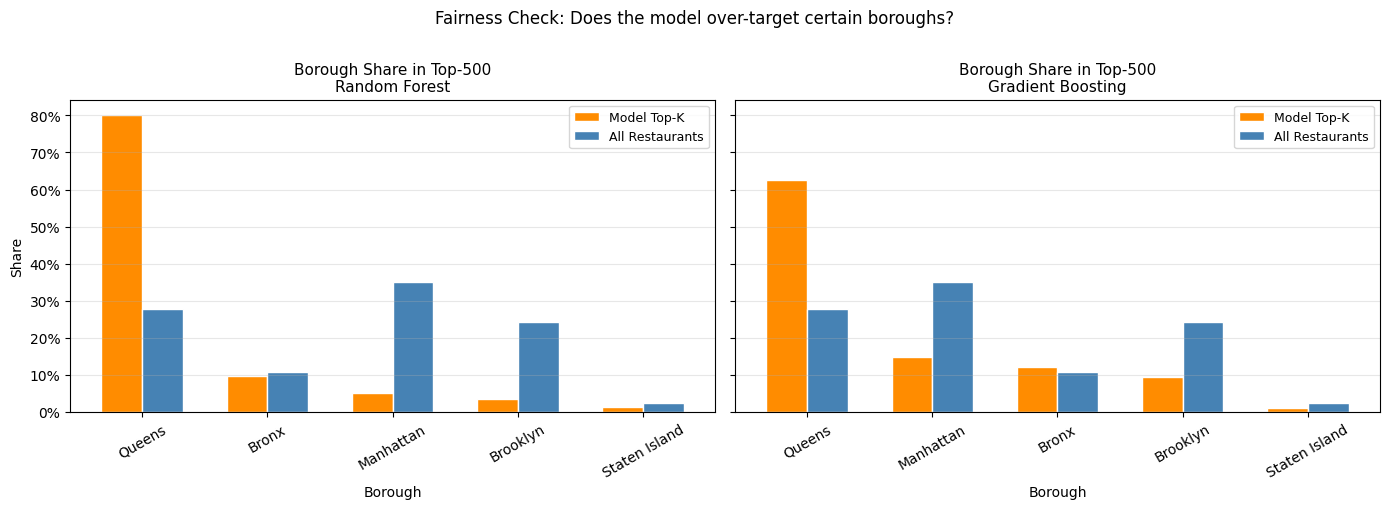

In [48]:
# 3.9b  Borough fairness bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (df_fair, title) in zip(axes, [
    (boro_rf, 'Random Forest'),
    (boro_gb, 'Gradient Boosting')
]):
    df_fair[['In Top-K','All Restaurants']].plot(
        kind='bar', ax=ax, color=['darkorange','steelblue'],
        edgecolor='white', width=0.65
    )
    ax.set_title(f'Borough Share in Top-{TOP_K}\n{title}', fontsize=11)
    ax.set_xlabel('Borough')
    ax.set_ylabel('Share')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.legend(['Model Top-K', 'All Restaurants'], fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fairness Check: Does the model over-target certain boroughs?',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('fairness_borough.png', dpi=150, bbox_inches='tight')
plt.show()

In [49]:
# 3.9c  Precision@K broken out by borough
# Does the model perform equally well across all boroughs?

boro_perf = []
for boro in test_df['boro'].dropna().unique():
    sub = test_df[test_df['boro'] == boro]
    if len(sub) < 20:
        continue
    k_b = max(1, int(TOP_K * len(sub) / len(test_df)))  # pro-rate K by borough size
    boro_perf.append({
        'Borough'          : boro,
        'N'                : len(sub),
        'Actual Crit Rate' : f"{sub['target'].mean():.2%}",
        'RF Precision@K'   : f"{precision_at_k(sub, 'score_rf',  k=k_b):.2%}",
        'GB Precision@K'   : f"{precision_at_k(sub, 'score_gb',  k=k_b):.2%}",
        'LR Precision@K'   : f"{precision_at_k(sub, 'baseline_logreg', k=k_b):.2%}",
    })

print("\n=== PRECISION@K BY BOROUGH ===")
print(pd.DataFrame(boro_perf).to_string(index=False))


=== PRECISION@K BY BOROUGH ===
      Borough    N Actual Crit Rate RF Precision@K GB Precision@K LR Precision@K
    Manhattan 3928           83.15%         86.78%         94.25%         83.33%
Staten Island  270           88.15%         66.67%         75.00%         75.00%
     Brooklyn 2734           82.22%         83.47%         82.64%         76.03%
        Bronx 1199           88.57%         94.34%         86.79%         79.25%
       Queens 3109           88.32%         89.86%         89.86%         81.16%


In [50]:
# 3.9d  Cuisine fairness (top 10 cuisine types)
cuisine_perf = []
top_c = test_df['cuisine_description'].value_counts().nlargest(10).index

for cuisine in top_c:
    sub = test_df[test_df['cuisine_description'] == cuisine]
    if len(sub) < 20:
        continue
    k_c = max(1, int(TOP_K * len(sub) / len(test_df)))
    cuisine_perf.append({
        'Cuisine'          : cuisine,
        'N'                : len(sub),
        'Actual Crit Rate' : f"{sub['target'].mean():.2%}",
        'RF Precision@K'   : f"{precision_at_k(sub, 'score_rf', k=k_c):.2%}",
        'GB Precision@K'   : f"{precision_at_k(sub, 'score_gb', k=k_c):.2%}",
    })

print("\n=== PRECISION@K BY CUISINE TYPE ===")
print(pd.DataFrame(cuisine_perf).to_string(index=False))


=== PRECISION@K BY CUISINE TYPE ===
                 Cuisine    N Actual Crit Rate RF Precision@K GB Precision@K
                American 1497           87.24%         87.88%         90.91%
                 Chinese 1215           87.24%         88.89%         92.59%
              Coffee/Tea  962           79.63%         80.95%         83.33%
          Latin American  632           90.98%         89.29%         85.71%
                   Pizza  627           87.40%         88.89%         92.59%
Bakery Products/Desserts  563           86.32%         84.00%         84.00%
               Caribbean  486           84.98%         80.95%         85.71%
                 Mexican  394           82.99%        100.00%        100.00%
                Japanese  346           83.82%         86.67%         86.67%
                 Chicken  336           86.01%        100.00%        100.00%


In [51]:
# ============================================================
# 3.10  EXPECTED VALUE / ROI FRAMING
# ============================================================
COST_PER_INSPECTION = 500   # Estimated USD — verify with DOHMH data in final writeup

base_prec = precision_at_k(test_df, 'baseline_time')
rf_prec   = precision_at_k(test_df, 'score_rf')
gb_prec   = precision_at_k(test_df, 'score_gb')

rows = []
for name, prec in [
    ('Time-Since-Last (Current)', base_prec),
    ('Random Forest',             rf_prec),
    ('Gradient Boosting',         gb_prec),
]:
    viols_wk  = TOP_K * prec
    cost_viol = (TOP_K * COST_PER_INSPECTION) / max(viols_wk, 1)
    extra     = viols_wk - (TOP_K * base_prec)
    rows.append({
        'Policy'              : name,
        'Precision@K'         : f"{prec:.2%}",
        'Violations/week'     : f"{viols_wk:.0f}",
        'Cost per violation'  : f"${cost_viol:,.0f}",
        'Extra caught vs now' : f"+{extra:.0f}/wk  (+{extra*52:.0f}/yr)"
        if extra > 0 else '—'
    })

print(f"\n{'='*70}")
print(f"  EXPECTED VALUE  |  K={TOP_K} inspections/week  |  ${COST_PER_INSPECTION}/inspection")
print(f"{'='*70}")
print(pd.DataFrame(rows).to_string(index=False))


  EXPECTED VALUE  |  K=500 inspections/week  |  $500/inspection
                   Policy Precision@K Violations/week Cost per violation Extra caught vs now
Time-Since-Last (Current)      87.40%             437               $572                   —
            Random Forest      90.60%             453               $552   +16/wk  (+832/yr)
        Gradient Boosting      90.60%             453               $552   +16/wk  (+832/yr)


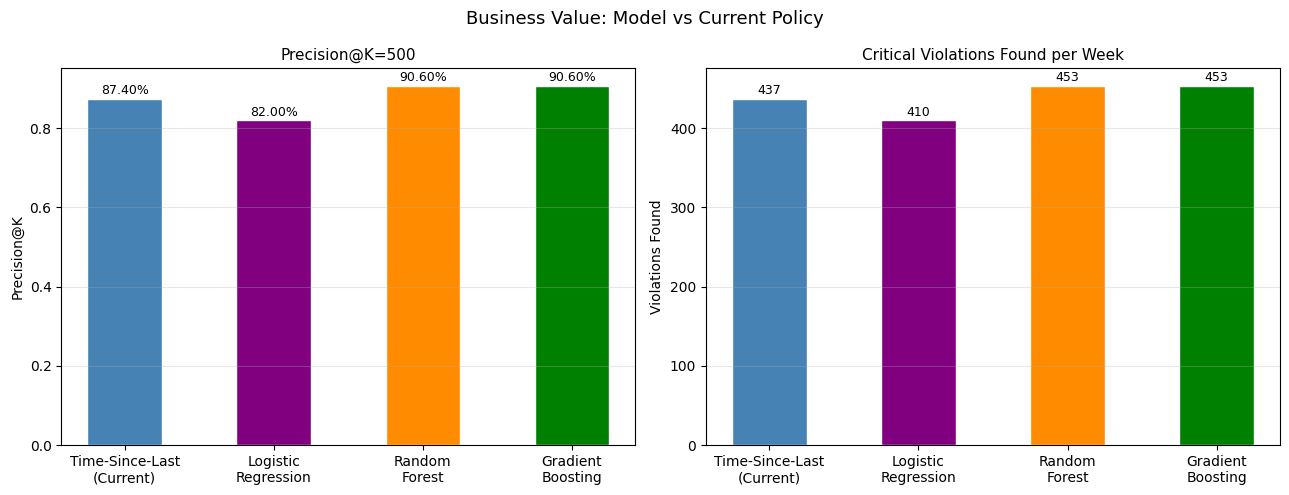

In [52]:
# Expected value bar chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Time-Since-Last\n(Current)', 'Logistic\nRegression',
          'Random\nForest', 'Gradient\nBoosting']
cols   = ['baseline_time','baseline_logreg','score_rf','score_gb']
colors = ['steelblue','purple','darkorange','green']
precs  = [precision_at_k(test_df, c) for c in cols]
viols  = [p * TOP_K for p in precs]

for ax, (vals, ylabel, title) in zip(axes, [
    (precs, 'Precision@K',       f'Precision@K={TOP_K}'),
    (viols, 'Violations Found',  f'Critical Violations Found per Week'),
]):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.005,
                f'{val:.2%}' if ylabel == 'Precision@K' else f'{val:.0f}',
                ha='center', va='bottom', fontsize=9)

if ylabel == 'Precision@K':
    axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.suptitle('Business Value: Model vs Current Policy', fontsize=13)
plt.tight_layout()
plt.savefig('expected_value.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# ============================================================
# 3.11  KNOWN ISSUES LOG  (for Status Report)
# ============================================================
print("""
KNOWN ISSUES & OPEN QUESTIONS
==============================

[CRITICAL] 1. CRITICAL FLAG PARSING BUG
   str.contains('critical') matches 'Not Critical', inflating
   critical rate to ~98%. Fix: use exact match == 'critical'.
   Until fixed, all Precision@K values (~95-99%) are misleading.

[ACKNOWLEDGED] 2. SELECTION BIAS
   Only previously inspected restaurants have labels.
   Never-inspected restaurants cannot be scored.
   Will be discussed explicitly in the final writeup.

[FLAGGED] 3. FEEDBACK LOOP RISK
   Deploying the model may cause over-inspection of already
   frequently inspected areas, amplifying existing patterns.
   Mitigated by the borough/cuisine fairness monitoring above.

[NEXT STEPS] 4. FEATURES TO ADD IN FINAL WRITEUP
   - 311 complaint volume per restaurant
   - Number of re-inspections (persistent problems signal)
   - Rolling 12-month violation rate
   - Inspection type (initial vs re-inspection) as a feature

[FUTURE WORK] 5. HYPERPARAMETER TUNING
   Current models use sensible defaults. GridSearchCV with
   TimeSeriesSplit could squeeze out more performance.
""")


KNOWN ISSUES & OPEN QUESTIONS

[CRITICAL] 1. CRITICAL FLAG PARSING BUG
   str.contains('critical') matches 'Not Critical', inflating
   critical rate to ~98%. Fix: use exact match == 'critical'.
   Until fixed, all Precision@K values (~95-99%) are misleading.

[ACKNOWLEDGED] 2. SELECTION BIAS
   Only previously inspected restaurants have labels.
   Never-inspected restaurants cannot be scored.
   Will be discussed explicitly in the final writeup.

[FLAGGED] 3. FEEDBACK LOOP RISK
   Deploying the model may cause over-inspection of already
   frequently inspected areas, amplifying existing patterns.
   Mitigated by the borough/cuisine fairness monitoring above.

[NEXT STEPS] 4. FEATURES TO ADD IN FINAL WRITEUP
   - 311 complaint volume per restaurant
   - Number of re-inspections (persistent problems signal)
   - Rolling 12-month violation rate
   - Inspection type (initial vs re-inspection) as a feature

[FUTURE WORK] 5. HYPERPARAMETER TUNING
   Current models use sensible defaults. Gr